In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
!pip uninstall -y torchvision torchaudio -q
# To pretent Version Conflict
!pip install -q -U transformers datasets accelerate scikit-learn evaluate seqeval matplotlib

In [41]:
import os, sys, json, inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset, DatasetDict

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import TrainerCallback
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
    DataCollatorForTokenClassification,
    set_seed,
)

from seqeval.metrics import (
    precision_score as seq_precision,
    recall_score as seq_recall,
    f1_score as seq_f1,
    classification_report as seq_classification_report,
)

In [42]:
assert "torchvision" not in sys.modules, "torchvision got imported — restart runtime and re-run."
RND = 42
set_seed(RND)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("GPU:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

QUICK_TEST = False
QUICK_TEST_N = 1000

GPU: True Tesla T4


#### Configuration

In [43]:
MODEL_CHOICE = "xlmr"
MODEL_REGISTERY = {
    # There're 3 Pretrained options for Benchmarketing
    "parsbert" : "HooshvareLab/bert-fa-zwnj-base",  # Customized for Persian -> BERT
    "xlmr" : "xlm-roberta-base",  # Trained on about 100 language including Persian
    "modernbert_fa" : "myrkur/Persian-ModernBert-base"  # The newest Persian model -> ModernBERT
}

MODEL_NAME = MODEL_REGISTERY[MODEL_CHOICE]
print(f"\nUsing backbone: {MODEL_CHOICE} -> {MODEL_NAME}")

MAX_LENGTH = 128  # Maximum number of Tokens -> if len > MAX => Cut
                  #                             if len < MAX => Padding
FOCAL_GAMMA = 2.0 # (weight) How deep focus on hard/less samples
FOCAL_GAMMA_ASPECT = 2.0 # Same for Aspect
NUM_EPOCHS_SENTIMENT = 8
NUM_EPOCHS_ASPECT = 8
ASPECT_WISE_MIN_SAMPLES = 5 # Ignore those Aspects which their num is less than "x" in dataset
EARLY_STOPPING_PATIENCE = 3


Using backbone: xlmr -> xlm-roberta-base


#### Load Dataset

In [44]:
raw = load_dataset("ParsiAI/Pars-ABSA")
print(raw)

df_train_full = raw["train"].to_pandas()
df_val_full = raw["validation"].to_pandas() if "validation" in raw else None
df_test_full = raw["test"].to_pandas() if "test" in raw else None

DatasetDict({
    train: Dataset({
        features: ['text', 'from', 'to', 'term', 'polarity'],
        num_rows: 7501
    })
    validation: Dataset({
        features: ['text', 'from', 'to', 'term', 'polarity'],
        num_rows: 1251
    })
    test: Dataset({
        features: ['text', 'from', 'to', 'term', 'polarity'],
        num_rows: 1250
    })
})


In [45]:
text_col, aspect_col, label_col, from_col, to_col = "text", "term", "polarity", "from", "to"
print("Using columns ->", text_col, aspect_col, label_col, from_col, to_col)

def build_pair_fields(df):  # Review + Aspect
    df = df.copy()
    has_from_to = from_col in df.columns and to_col in df.columns

    texts = df[text_col].astype(str).tolist()
    terms = df[aspect_col].astype(str).tolist()
    froms = df[from_col].tolist() if has_from_to else [None] * len(df)
    tos = df[to_col].tolist() if has_from_to else [None] * len(df)

    review_texts = []
    starts = []
    ends = []

    n_from_to = 0
    n_placeholder = 0
    n_substring = 0
    n_failed = 0

    for text, term, f, t in zip(texts, terms, froms, tos):
        start = -1
        end = -1
        review_text = text

        # Use from/to
        if f is not None and t is not None:
            try:
                f_i = int(f)
                t_i = int(t)
                if (
                    0 <= f_i < t_i <= len(text)
                    and text[f_i:t_i] == term
                ):
                    start = f_i
                    end = t_i
                    n_from_to +=1

            except (ValueError,TypeError):
                pass

        # Use placeholder
        if start == -1:
            idx = text.find("$T$")
            if idx != -1:
                review_text = text[:idx] + term+ text[idx + 3:]
                start = idx
                end = idx + len(term)
                n_placeholder +=1

        # Use direct search for term
        if start == -1:
            idx = text.find(term)
            if idx != -1:
                start = idx
                end = idx + len(term)
                n_substring +=1
            else:
                n_failed +=1

        review_texts.append(review_text)
        starts.append(start)
        ends.append(end)

    df["review_text"] = review_texts
    df["aspect_text"] = terms
    df["asp_start"] = starts
    df["asp_end"] = ends

    total = len(df)
    print (
        f"[build_pair_fields] "
        f"Resource span aspect -> {from_col}/{to_col}: {n_from_to}/{total} | "
        f"$T$ placeholder: {n_placeholder}/{total} | "
        f"substring search: {n_substring}/{total} | "
        f"Not Found (asp_start=-1): {n_failed}/{total}"
    )
    return df

Using columns -> text term polarity from to


In [46]:
df_train_full = build_pair_fields(df_train_full)

if df_val_full is not None:
    df_val_full = build_pair_fields(df_val_full)

if df_test_full is not None:
    df_test_full = build_pair_fields(df_test_full)

[build_pair_fields] Resource span aspect -> from/to: 41/7501 | $T$ placeholder: 0/7501 | substring search: 7410/7501 | Not Found (asp_start=-1): 50/7501
[build_pair_fields] Resource span aspect -> from/to: 3/1251 | $T$ placeholder: 0/1251 | substring search: 1236/1251 | Not Found (asp_start=-1): 12/1251
[build_pair_fields] Resource span aspect -> from/to: 4/1250 | $T$ placeholder: 0/1250 | substring search: 1235/1250 | Not Found (asp_start=-1): 11/1250


#### Sanity Check

In [47]:
n_valid_span = int((df_train_full["asp_start"] >= 0).sum())

print(
    f"[sanity check] Valid aspect spans: "
    f"{n_valid_span}/{len(df_train_full)}"
)

if n_valid_span > 0:

    row = df_train_full[df_train_full["asp_start"] >= 0].iloc[0] # [0] is review_text

    extracted = row["review_text"][row["asp_start"]:row["asp_end"]]

    print(
        f"[sanity check] "
        f"Aspect = '{row['aspect_text']}' | "
        f"Extracted = '{extracted}' | "
        f"{'PASS' if extracted == row['aspect_text'] else 'FAIL'}"
    )

else:

    print(
    "[sanity check] ERROR: No valid aspect spans were found. "
    "The Aspect Detection model cannot be trained."
    )

[sanity check] Valid aspect spans: 7451/7501
[sanity check] Aspect = 'پدش' | Extracted = 'پدش' | PASS


In [48]:
if QUICK_TEST:
    print(f"\nQUICK_TEST is ON — using only the first {QUICK_TEST_N} training samples.")
    df_train_full = df_train_full.head(QUICK_TEST_N).reset_index(drop=True)

#### Labels (sentiments)

In [49]:
raw_labels = sorted(df_train_full[label_col].astype(str).unique())
label2id = {lab: i for i, lab in enumerate(raw_labels)}
id2label = {i: lab for lab, i in label2id.items()}
print("\nLabel mapping (sentiment):", label2id)

for d in [df_train_full, df_val_full, df_test_full]:
    if d is not None:
        d["label_id"] = d[label_col].astype(str).map(label2id)

print("Class counts (train subset):\n", df_train_full[label_col].value_counts())



Label mapping (sentiment): {'negative': 0, 'neutral': 1, 'positive': 2}
Class counts (train subset):
 polarity
positive    3833
negative    2282
neutral     1386
Name: count, dtype: int64


In [50]:
aspect_label_list = ["O", "B-ASP", "I-ASP"]
aspect_label2id = {lab: i for i, lab in enumerate(aspect_label_list)}
aspect_id2label = {i: lab for lab, i in aspect_label2id.items()}

#### Split Data

In [51]:
try:
    train_df, val_df_from_train = train_test_split(
        df_train_full, test_size=0.2, random_state=RND, stratify=df_train_full["label_id"]
    )
except ValueError as e:
    print("Stratified split failed, falling back:", e)
    train_df, val_df_from_train = train_test_split(df_train_full, test_size=0.15, random_state=RND)

if QUICK_TEST:
    val_df, test_df = train_test_split(val_df_from_train, test_size=0.5, random_state=RND)
else:
    val_df = df_val_full
    test_df = df_test_full

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\nSizes -> train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")


Sizes -> train: 6000  val: 1251  test: 1250


#### Class Weight & Tokenize

In [52]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(label2id.values())),
    y=train_df["label_id"].values
)
class_weights_t = torch.tensor(class_weights, dtype=torch.float)
print("Class weights (focal alpha):", dict(zip([id2label[i] for i in sorted(label2id.values())], class_weights)))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if not tokenizer.is_fast:
  raise ValueError(
      f"Tokenizer '{MODEL_NAME}' is not a Fast tokenizer, "
      "but a Fast tokenizer is required for aspect extraction "
      "because offset_mapping is needed. "
      "Please choose another model from MODEL_REGISTRY."
  )

Class weights (focal alpha): {'negative': np.float64(1.095890410958904), 'neutral': np.float64(1.8034265103697025), 'positive': np.float64(0.6523157208088715)}


#### Confusion Matrix

In [53]:
def plot_and_save_confusion_matrix(y_true, y_pred, label_ids, label_names, title, save_path):
    cm = confusion_matrix(y_true, y_pred, labels=label_ids)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"[confusion matrix] saved in : {save_path}")

#### Preparing Data

In [54]:
num_labels = len(label2id)  # To determine how many outputs we should have for our customized Classification

sentiment_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels, id2label=id2label, label2id=label2id,
    torch_dtype=torch.float32,
)

def preprocess_sentiment(batch):
    return tokenizer(
        batch["aspect_text"],
        batch["review_text"],
        truncation="only_second",
        max_length=MAX_LENGTH,
    )

keep_cols_sent = ["review_text", "aspect_text", "label_id"]
sent_ds = DatasetDict({
    "train": Dataset.from_pandas(train_df[keep_cols_sent]),
    "validation": Dataset.from_pandas(val_df[keep_cols_sent]),
    "test": Dataset.from_pandas(test_df[keep_cols_sent]),
})
sent_ds = sent_ds.map(preprocess_sentiment, batched=True)

for split in sent_ds:
    cols_to_remove = [c for c in ["review_text", "aspect_text", "__index_level_0__"] if c in sent_ds[split].column_names]
    if cols_to_remove:
        sent_ds[split] = sent_ds[split].remove_columns(cols_to_remove)
    if "label_id" in sent_ds[split].column_names:
        sent_ds[split] = sent_ds[split].rename_column("label_id", "labels")

sent_columns_for_torch = [c for c in ["input_ids", "attention_mask", "token_type_ids", "labels"] if c in sent_ds["train"].column_names]
sent_ds.set_format(type="torch", columns=sent_columns_for_torch)

data_collator_sentiment = DataCollatorWithPadding(tokenizer=tokenizer)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1251 [00:00<?, ? examples/s]

Map:   0%|          | 0/1250 [00:00<?, ? examples/s]

#### Metrics

In [55]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=-1)
        probs = log_probs.exp()
        targets_one_hot = F.one_hot(targets, num_classes=logits.size(-1)).float()
        pt = (probs * targets_one_hot).sum(dim=-1).clamp(min=1e-8)
        log_pt = (log_probs * targets_one_hot).sum(dim=-1)
        focal_term = (1.0 - pt).pow(self.gamma)
        loss = -focal_term * log_pt
        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]
            loss = alpha_t * loss
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

def compute_metrics_sentiment(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {"accuracy": accuracy_score(labels, preds), "f1_macro": f1_score(labels, preds, average="macro", zero_division=0)}


class FocalTrainer(Trainer):
    def __init__(self, *args, focal_alpha=None, focal_gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss_fct = FocalLoss(alpha=focal_alpha, gamma=focal_gamma)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.focal_loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss



#### Related to Model

In [56]:
def build_training_args(output_dir, metric_for_best_model, num_epochs, greater_is_better=True):
    # تشخیص خودکار برای T4
    if torch.cuda.is_available():
        cap = torch.cuda.get_device_capability(0)
        print(f"GPU Capability: {cap[0]}.{cap[1]}")

        if cap[0] >= 8:  # A100, H100
            use_fp16 = False
            use_bf16 = True
            print("Using BFloat16")
        else:  # T4, V100 و قدیمی‌تر
            use_fp16 = True   # T4 از FP16 پشتیبانی می‌کند
            use_bf16 = False  # اما از BFloat16 نه!
            print("Using FP16")
    else:
        use_fp16 = False
        use_bf16 = False
        print("Using CPU, no mixed precision")

    common_kwargs = dict(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=20,
        load_best_model_at_end=False,
        metric_for_best_model=metric_for_best_model,
        greater_is_better=greater_is_better,
        fp16=use_fp16,
        bf16=use_bf16,
        save_total_limit=1,
    )


    # To fix Version problems
    ta_params = inspect.signature(TrainingArguments.__init__).parameters
    if "eval_strategy" in ta_params:
        common_kwargs["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in ta_params:
        common_kwargs["evaluation_strategy"] = "epoch"
    if "save_strategy" in ta_params:
        common_kwargs["save_strategy"] = "no"   # هیچ چک‌پوینتی روی دیسک نوشته نشه
    if "logging_strategy" in ta_params:
        common_kwargs["logging_strategy"] = "steps"
    if "warmup_ratio" in ta_params:
        common_kwargs["warmup_ratio"] = 0.1
    return TrainingArguments(**common_kwargs)


def build_trainer_kwargs(model, args, train_dataset, eval_dataset, compute_metrics):
    trainer_params = inspect.signature(Trainer.__init__).parameters
    kwargs = {
        "model": model, "args": args,
        "train_dataset": train_dataset, "eval_dataset": eval_dataset,
        "compute_metrics": compute_metrics,
    }
    if "processing_class" in trainer_params:
        kwargs["processing_class"] = tokenizer
    elif "tokenizer" in trainer_params:
        kwargs["tokenizer"] = tokenizer
    return kwargs

In [57]:
class BestModelInMemoryCallback(TrainerCallback):
    def __init__(self, metric_name, greater_is_better=True):
        self.metric_key = metric_name if metric_name.startswith("eval_") else f"eval_{metric_name}"
        self.greater_is_better = greater_is_better
        self.best_metric = None
        self.best_state_dict = None

    def on_evaluate(self, args, state, control, metrics=None, model=None, **kwargs):
        if metrics is None or model is None or self.metric_key not in metrics:
            return
        current = metrics[self.metric_key]
        is_better = (
            self.best_metric is None or
            (current > self.best_metric if self.greater_is_better else current < self.best_metric)
        )
        if is_better:
            self.best_metric = current
            self.best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print(f"✅ بهترین مدل جدید ذخیره شد توی RAM — {self.metric_key} = {current:.4f}")

In [58]:
sentiment_output_dir = "/content/drive/MyDrive/pars_absa_sentiment_model"
sentiment_args = build_training_args(sentiment_output_dir, "f1_macro", NUM_EPOCHS_SENTIMENT)
best_cb_sentiment = BestModelInMemoryCallback(metric_name="f1_macro", greater_is_better=True)

sentiment_trainer = FocalTrainer(
    **build_trainer_kwargs(sentiment_model, sentiment_args, sent_ds["train"], sent_ds["validation"], compute_metrics_sentiment),
    focal_alpha=class_weights_t,
    focal_gamma=FOCAL_GAMMA,
    data_collator=data_collator_sentiment,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE), best_cb_sentiment],
)

print("\nTraining sentiment classifier...")
try:
    sentiment_trainer.train()
finally:
    if best_cb_sentiment.best_state_dict is not None:
        sentiment_model.load_state_dict(best_cb_sentiment.best_state_dict)
        print(f"بهترین مدل (f1_macro={best_cb_sentiment.best_metric:.4f}) لود شد برای سیو نهایی")
    os.makedirs(sentiment_output_dir, exist_ok=True)
    sentiment_trainer.save_model(sentiment_output_dir)
    tokenizer.save_pretrained(sentiment_output_dir)
    with open(os.path.join(sentiment_output_dir, "label2id.json"), "w", encoding="utf-8") as f:
        json.dump({"label2id": label2id, "id2label": id2label}, f, ensure_ascii=False, indent=2)
    print("✅ مدل sentiment سیو شد")

print("\nEvaluating sentiment model on test set...")
print(sentiment_trainer.evaluate(eval_dataset=sent_ds["test"]))
sent_preds_output = sentiment_trainer.predict(sent_ds["test"])
sent_preds = np.argmax(sent_preds_output.predictions, axis=1)
sent_true = np.array(sent_ds["test"]["labels"])
present_labels = sorted(set(sent_true.tolist()) | set(sent_preds.tolist()))
present_label_names = [id2label[i] for i in present_labels]

print(classification_report(
    sent_true, sent_preds, labels=present_labels,
    target_names=present_label_names, zero_division=0
))

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


GPU Capability: 7.5
Using FP16


[transformers] Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.



Training sentiment classifier...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.323867,0.319412,0.726619,0.709487
2,0.158441,0.188004,0.848921,0.836915
3,0.151969,0.199451,0.843325,0.829566
4,0.088717,0.249705,0.876898,0.863290
5,0.070185,0.283013,0.884093,0.872717
6,0.077512,0.241908,0.891287,0.881362
7,0.027483,0.335009,0.881695,0.867995
8,0.020226,0.332246,0.886491,0.874316


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ مدل sentiment سیو شد

Evaluating sentiment model on test set...


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.020226,0.256599,8,0.888000,0.871645


{'eval_loss': 0.25659921765327454, 'eval_accuracy': 0.888, 'eval_f1_macro': 0.8716446224500766}


              precision    recall  f1-score   support

    negative       0.88      0.90      0.89       410
     neutral       0.83      0.80      0.82       208
    positive       0.91      0.91      0.91       632

    accuracy                           0.89      1250
   macro avg       0.87      0.87      0.87      1250
weighted avg       0.89      0.89      0.89      1250



####

Sentiment Evaluation

Class-wise F1 scores (sentiment): {'negative': 0.888, 'neutral': 0.816, 'positive': 0.911}


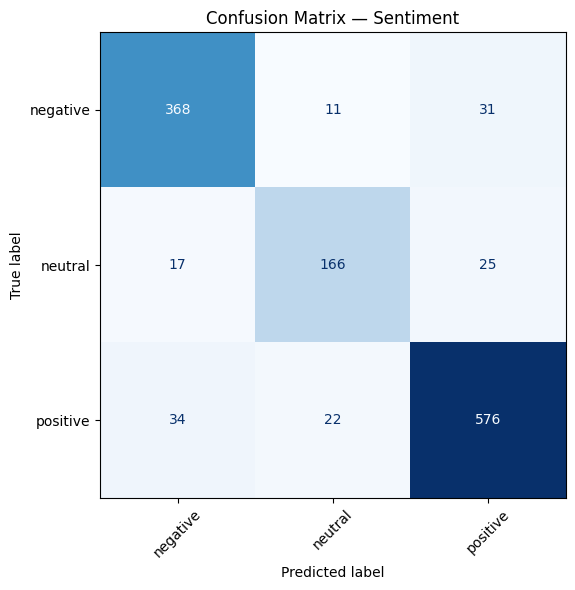

[confusion matrix] saved in : /content/drive/MyDrive/pars_absa_sentiment_model/confusion_matrix_sentiment.png


In [59]:
per_class_f1_sentiment = f1_score(sent_true, sent_preds, labels=present_labels, average=None, zero_division=0)
print("Class-wise F1 scores (sentiment):",
      {name: round(float(v), 3) for name, v in zip(present_label_names, per_class_f1_sentiment)})

os.makedirs(sentiment_output_dir, exist_ok=True)
plot_and_save_confusion_matrix(
    sent_true, sent_preds, present_labels, present_label_names,
    title="Confusion Matrix — Sentiment",
    save_path=os.path.join(sentiment_output_dir, "confusion_matrix_sentiment.png"),
)



#### Save Tokenizer Model & label2id/id2label

In [60]:
sentiment_trainer.save_model(sentiment_output_dir)
try:
    tokenizer.save_pretrained(sentiment_output_dir)
except Exception:
    pass

with open(os.path.join(sentiment_output_dir, "label2id.json"), "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id, "id2label": id2label}, f, ensure_ascii=False, indent=2)
print(f"label2id/id2label Saved in : {os.path.join(sentiment_output_dir, 'label2id.json')}")

sentiment_model.eval().to(device)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

label2id/id2label Saved in : /content/drive/MyDrive/pars_absa_sentiment_model/label2id.json


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=3, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

#### Aspect-wise F1 report

In [61]:
def aspect_wise_report(test_df_local, preds, true_ids, min_samples=ASPECT_WISE_MIN_SAMPLES):
    tmp = test_df_local.copy().reset_index(drop=True)
    tmp["pred_label_id"] = preds
    tmp["true_label_id"] = true_ids
    tmp["aspect_norm"] = tmp["aspect_text"].astype(str).str.strip().str.lower()

    rows = []
    for aspect, group in tmp.groupby("aspect_norm"):
        if len(group) < min_samples:
            continue
        f1 = f1_score(group["true_label_id"], group["pred_label_id"], average="macro", zero_division=0)
        acc = accuracy_score(group["true_label_id"], group["pred_label_id"])
        rows.append({"aspect": aspect, "n_samples": len(group), "accuracy": round(acc, 3), "f1_macro": round(f1, 3)})

    report_df = pd.DataFrame(rows)
    if len(report_df):
        report_df = report_df.sort_values("f1_macro").reset_index(drop=True)
    return report_df

print(f"\nAspect-wise F1 (only aspects with at least {ASPECT_WISE_MIN_SAMPLES} samples in test)")
aw_report = aspect_wise_report(test_df, sent_preds, sent_true)
if len(aw_report):
    print(aw_report.to_string(index=False))
else:
    print("In this test set (especially with QUICK_TEST=True), no aspect reached the minimum sample threshold.")
    print("This report will become more meaningful when QUICK_TEST=False.")


Aspect-wise F1 (only aspects with at least 5 samples in test)
      aspect  n_samples  accuracy  f1_macro
   اثر انگشت          5     0.600     0.286
    این قیمت          5     0.600     0.433
       گوشیه         19     0.947     0.486
        مودم          9     0.778     0.508
         بیس          7     0.857     0.600
        قیمت         19     0.895     0.611
       قیمتش         25     0.880     0.614
      باطریش         10     0.700     0.667
 دوربین سلفی          8     0.750     0.711
   دیجی کالا         12     0.750     0.750
        گوشی         82     0.951     0.754
دوربین سلفیش          5     0.800     0.800
     دوربینش         17     0.882     0.808
  صفحه نمایش         18     0.833     0.827
      کیفیتش         14     0.857     0.849
       سرعتش          8     0.875     0.859
    این گوشی         51     0.961     0.861
      دوربین         27     0.889     0.862
    ماندگاری         10     0.900     0.863
      باتریش         16     0.875     0.863
 کیفیت ساختش 

#### Aspect Detection (BIO)

In [62]:
aspect_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(aspect_label_list),
    id2label=aspect_id2label,
    label2id=aspect_label2id,
    torch_dtype=torch.float32,
)

def align_labels_with_tokens(offsets, start_char, end_char):
    labels = []
    inside = False
    for (s, e) in offsets:
        if s == 0 and e == 0:
            labels.append(-100)
            continue
        if start_char < 0 or e <= start_char or s >= end_char:
            labels.append(aspect_label2id["O"])
            inside = False
        else:
            if not inside:
                labels.append(aspect_label2id["B-ASP"])
                inside = True
            else:
                labels.append(aspect_label2id["I-ASP"])
    return labels


def align_labels_with_tokens_multi(offsets, spans):
    labels = []
    for (s, e) in offsets:
        if s == 0 and e == 0:
            labels.append(-100)
        else:
            labels.append(aspect_label2id["O"])

    for start_char, end_char in spans:
        inside = False
        for i, (s, e) in enumerate(offsets):
            if s == 0 and e == 0:
                continue
            if e <= start_char or s >= end_char:
                continue
            if not inside:
                labels[i] = aspect_label2id["B-ASP"]
                inside = True
            else:
                labels[i] = aspect_label2id["I-ASP"]
    return labels

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


#### Preprocess Aspect Extraction

In [65]:
def build_multi_span_df(df):
    """هر ردیف را بر اساس review_text گروه‌بندی می‌کند و همه‌ی span های معتبر آن ریویو را جمع می‌کند."""
    valid = df[df["asp_start"] >= 0].copy()
    grouped = (
        valid.groupby("review_text")
        .apply(lambda g: list(zip(g["asp_start"].tolist(), g["asp_end"].tolist())))
        .reset_index(name="spans")
    )
    return grouped

train_asp_grouped = build_multi_span_df(train_df)
val_asp_grouped = build_multi_span_df(val_df)
test_asp_grouped = build_multi_span_df(test_df)

print(f"قبل از ادغام -> train: {len(train_df)} ردیف")
print(f"بعد از ادغام -> train: {len(train_asp_grouped)} ریویوی یکتا")

def align_labels_with_tokens_multi(offsets, spans):
    labels = []
    for (s, e) in offsets:
        if s == 0 and e == 0:
            labels.append(-100)
        else:
            labels.append(aspect_label2id["O"])

    for start_char, end_char in spans:
        inside = False
        for i, (s, e) in enumerate(offsets):
            if s == 0 and e == 0:
                continue
            if e <= start_char or s >= end_char:
                continue
            if not inside:
                labels[i] = aspect_label2id["B-ASP"]
                inside = True
            else:
                labels[i] = aspect_label2id["I-ASP"]
    return labels

def preprocess_aspect_extraction_multi(examples):
    tokenized = tokenizer(
        examples["review_text"],
        truncation=True,
        max_length=MAX_LENGTH,
        return_offsets_mapping=True,
    )
    offsets = tokenized["offset_mapping"]
    spans = examples["spans"]
    tokenized["labels"] = align_labels_with_tokens_multi(offsets, spans)
    tokenized.pop("offset_mapping")
    return tokenized

asp_ds = DatasetDict({
    "train": Dataset.from_pandas(train_asp_grouped[["review_text", "spans"]]),
    "validation": Dataset.from_pandas(val_asp_grouped[["review_text", "spans"]]),
    "test": Dataset.from_pandas(test_asp_grouped[["review_text", "spans"]]),
})
asp_ds = asp_ds.map(preprocess_aspect_extraction_multi, batched=False)

for split in asp_ds:
    cols_to_remove = [c for c in ["review_text", "spans", "__index_level_0__"] if c in asp_ds[split].column_names]
    if cols_to_remove:
        asp_ds[split] = asp_ds[split].remove_columns(cols_to_remove)

asp_columns_for_torch = [c for c in ["input_ids", "attention_mask", "token_type_ids", "labels"] if c in asp_ds["train"].column_names]
asp_ds.set_format(type="torch", columns=asp_columns_for_torch)

/tmp/ipykernel_1115/3554077417.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: list(zip(g["asp_start"].tolist(), g["asp_end"].tolist())))
/tmp/ipykernel_1115/3554077417.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: list(zip(g["asp_start"].tolist(), g["asp_end"].tolist())))
/tmp/ipykernel_1115/3554077417.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on 

قبل از ادغام -> train: 6000 ردیف
بعد از ادغام -> train: 4032 ریویوی یکتا


Map:   0%|          | 0/4032 [00:00<?, ? examples/s]

Map:   0%|          | 0/1117 [00:00<?, ? examples/s]

Map:   0%|          | 0/1109 [00:00<?, ? examples/s]

In [66]:
# DataCollator
data_collator_aspect = DataCollatorForTokenClassification(tokenizer=tokenizer, label_pad_token_id=-100)

class TokenFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, ignore_index=-100):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        logits_flat = logits.view(-1, logits.size(-1))
        targets_flat = targets.view(-1)
        mask = targets_flat != self.ignore_index
        logits_flat = logits_flat[mask]
        targets_flat = targets_flat[mask]

        log_probs = F.log_softmax(logits_flat, dim=-1)
        probs = log_probs.exp()
        targets_one_hot = F.one_hot(targets_flat, num_classes=logits_flat.size(-1)).float()
        pt = (probs * targets_one_hot).sum(dim=-1).clamp(min=1e-8)
        log_pt = (log_probs * targets_one_hot).sum(dim=-1)
        focal_term = (1.0 - pt).pow(self.gamma)
        loss = -focal_term * log_pt
        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets_flat]
            loss = alpha_t * loss
        return loss.mean()


In [67]:
class AspectFocalTrainer(Trainer):
    def __init__(self, *args, focal_alpha=None, focal_gamma=2.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss_fct = TokenFocalLoss(alpha=focal_alpha, gamma=focal_gamma)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.focal_loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics_aspect(pred):
    predictions = np.argmax(pred.predictions, axis=2)
    labels = pred.label_ids
    true_predictions = [
        [aspect_id2label[p] for p, l in zip(pred_row, label_row) if l != -100]
        for pred_row, label_row in zip(predictions, labels)
    ]
    true_labels_seq = [
        [aspect_id2label[l] for p, l in zip(pred_row, label_row) if l != -100]
        for pred_row, label_row in zip(predictions, labels)
    ]
    return {
        "precision": seq_precision(true_labels_seq, true_predictions),
        "recall": seq_recall(true_labels_seq, true_predictions),
        "f1": seq_f1(true_labels_seq, true_predictions),
    }

In [68]:
_all_token_labels = []
for lab_seq in asp_ds["train"]["labels"]:
    lab_list = lab_seq.tolist() if hasattr(lab_seq, "tolist") else list(lab_seq)
    _all_token_labels.extend([l for l in lab_list if l != -100])
_all_token_labels = np.array(_all_token_labels)

if len(np.unique(_all_token_labels)) < len(aspect_label_list):
    print("Warning: At least one BIO class was not seen in the train subset. Using uniform weights.")
    aspect_class_weights_raw = None
    aspect_class_weights_t = torch.ones(len(aspect_label_list))
else:
    aspect_class_weights_raw = compute_class_weight(
        class_weight="balanced",
        classes=np.array(sorted(aspect_label2id.values())),
        y=_all_token_labels,
    )
    # وزن متوسط: نه صفر (حذف کامل)، نه sqrt کامل (که خیلی تهاجمی بود)
    # سقف ۳.۵ می‌ذاریم تا نه مدل بیش‌ازحد ASP بزنه، نه بیش‌ازحد O
    capped_weights = np.clip(np.sqrt(aspect_class_weights_raw), a_min=1.0, a_max=3.5)
    aspect_class_weights_t = torch.tensor(capped_weights, dtype=torch.float)

print("Token class weights (capped):", dict(zip(aspect_label_list, aspect_class_weights_t.tolist())))

if aspect_class_weights_raw is not None:
    print("Raw token class weights (before adjustment):", dict(zip(aspect_label_list, aspect_class_weights_raw.tolist())))
# print("Token class weights (aspect focal alpha, after sqrt dampening):",
      # dict(zip(aspect_label_list, aspect_class_weights_t.tolist())))


Token class weights (capped): {'O': 1.0, 'B-ASP': 3.5, 'I-ASP': 3.4160025119781494}
Raw token class weights (before adjustment): {'O': 0.35059437330905474, 'B-ASP': 16.127903522842036, 'I-ASP': 11.669073715882227}


#### Train Aspect Model

In [69]:
aspect_output_dir = "/content/drive/MyDrive/pars_absa_aspect_model"
aspect_args = build_training_args(aspect_output_dir, "f1", NUM_EPOCHS_ASPECT)
aspect_trainer_kwargs = build_trainer_kwargs(aspect_model, aspect_args, asp_ds["train"], asp_ds["validation"], compute_metrics_aspect)
best_cb_aspect = BestModelInMemoryCallback(metric_name="f1", greater_is_better=True)

aspect_trainer = AspectFocalTrainer(
    **aspect_trainer_kwargs,
    focal_alpha=aspect_class_weights_t,
    focal_gamma=FOCAL_GAMMA_ASPECT,
    data_collator=data_collator_aspect,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE), best_cb_aspect],
)

print("\nTraining aspect-extraction model (BIO tagging + Early Stopping)")
try:
    aspect_trainer.train()
finally:
    if best_cb_aspect.best_state_dict is not None:
        aspect_model.load_state_dict(best_cb_aspect.best_state_dict)
        print(f"بهترین مدل (f1={best_cb_aspect.best_metric:.4f}) لود شد برای سیو نهایی")
    os.makedirs(aspect_output_dir, exist_ok=True)
    aspect_trainer.save_model(aspect_output_dir)
    tokenizer.save_pretrained(aspect_output_dir)
    with open(os.path.join(aspect_output_dir, "label2id.json"), "w", encoding="utf-8") as f:
        json.dump({"label2id": aspect_label2id, "id2label": aspect_id2label}, f, ensure_ascii=False, indent=2)
    print("✅ مدل aspect سیو شد (حتی اگه خط بعدی ارور بده)")

print("\nEvaluating aspect-extraction model on test set...")
print(aspect_trainer.evaluate(eval_dataset=asp_ds["test"]))

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


GPU Capability: 7.5
Using FP16


[transformers] Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.



Training aspect-extraction model (BIO tagging + Early Stopping)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.085314,0.069467,0.190961,0.365564,0.250873
2,0.074115,0.083456,0.179493,0.678541,0.283889
3,0.065051,0.075521,0.199278,0.702290,0.310461
4,0.050518,0.078268,0.229801,0.588634,0.330555
5,0.049838,0.082591,0.233557,0.590331,0.334696
6,0.044680,0.089833,0.214571,0.636980,0.321009
7,0.038841,0.103542,0.225305,0.626802,0.331464
8,0.033715,0.110119,0.234360,0.613232,0.339118


✅ بهترین مدل جدید ذخیره شد توی RAM — eval_f1 = 0.2509
✅ بهترین مدل جدید ذخیره شد توی RAM — eval_f1 = 0.2839
✅ بهترین مدل جدید ذخیره شد توی RAM — eval_f1 = 0.3105
✅ بهترین مدل جدید ذخیره شد توی RAM — eval_f1 = 0.3306
✅ بهترین مدل جدید ذخیره شد توی RAM — eval_f1 = 0.3347
✅ بهترین مدل جدید ذخیره شد توی RAM — eval_f1 = 0.3391
بهترین مدل (f1=0.3391) لود شد برای سیو نهایی


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ مدل aspect سیو شد (حتی اگه خط بعدی ارور بده)

Evaluating aspect-extraction model on test set...


Training Loss,Validation Loss,Epoch,Precision,Recall,F1
0.033715,0.113980,8,0.219931,0.598131,0.321608


{'eval_loss': 0.11397965252399445, 'eval_precision': 0.21993127147766323, 'eval_recall': 0.5981308411214953, 'eval_f1': 0.32160804020100503}


#### Prediction & Save Reports


Aspect BIO per-class F1 report (seqeval)
              precision    recall  f1-score   support

         ASP       0.22      0.60      0.32      1177

   micro avg       0.22      0.60      0.32      1177
   macro avg       0.22      0.60      0.32      1177
weighted avg       0.22      0.60      0.32      1177



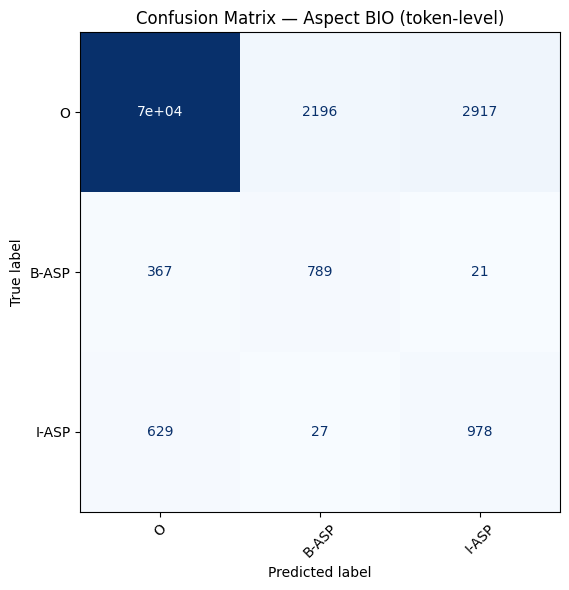

[confusion matrix] saved in : /content/drive/MyDrive/pars_absa_aspect_model/confusion_matrix_aspect_bio.png


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [70]:
asp_pred_output = aspect_trainer.predict(asp_ds["test"])
asp_predictions = np.argmax(asp_pred_output.predictions, axis=2)
asp_label_ids = asp_pred_output.label_ids

true_predictions_seq, true_labels_seq = [], []
flat_true_tokens, flat_pred_tokens = [], []
for pred_row, label_row in zip(asp_predictions, asp_label_ids):
    pr_seq, lb_seq = [], []
    for p, l in zip(pred_row, label_row):
        if l == -100:
            continue
        flat_true_tokens.append(int(l))
        flat_pred_tokens.append(int(p))
        pr_seq.append(aspect_id2label[int(p)])
        lb_seq.append(aspect_id2label[int(l)])
    true_predictions_seq.append(pr_seq)
    true_labels_seq.append(lb_seq)

print("\nAspect BIO per-class F1 report (seqeval)")
print(seq_classification_report(true_labels_seq, true_predictions_seq, zero_division=0))


os.makedirs(aspect_output_dir, exist_ok=True)
plot_and_save_confusion_matrix(
    flat_true_tokens, flat_pred_tokens,
    label_ids=list(range(len(aspect_label_list))), label_names=aspect_label_list,
    title="Confusion Matrix — Aspect BIO (token-level)",
    save_path=os.path.join(aspect_output_dir, "confusion_matrix_aspect_bio.png"),
)

aspect_trainer.save_model(aspect_output_dir)
try:
    tokenizer.save_pretrained(aspect_output_dir)
except Exception:
    pass

In [71]:
with open(os.path.join(aspect_output_dir, "label2id.json"), "w", encoding="utf-8") as f:
    json.dump({"label2id": aspect_label2id, "id2label": aspect_id2label}, f, ensure_ascii=False, indent=2)
print(f"label2id/id2label Saved in: {os.path.join(aspect_output_dir, 'label2id.json')}")

aspect_model.eval().to(device)

label2id/id2label Saved in: /content/drive/MyDrive/pars_absa_aspect_model/label2id.json


XLMRobertaForTokenClassification(
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=768, out_features=3, bias=True)
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
 

In [72]:
def format_prediction_card(aspect, sentiment, confidence):
    return (
        f"Aspect     : {aspect}\n"
        f"Sentiment  : {sentiment}\n"
        f"Confidence : {confidence:.2f}\n"
    )

def predict_dataframe(df, review_col="review", aspect_col="aspect", batch_size=32):
    reviews = df[review_col].astype(str).tolist()
    aspects = df[aspect_col].astype(str).tolist()

    sentiments, confidences = [], []
    sentiment_model.eval()
    with torch.no_grad():
        for i in range(0, len(reviews), batch_size):
            batch_reviews = reviews[i:i + batch_size]
            batch_aspects = aspects[i:i + batch_size]
            enc = tokenizer(
                batch_aspects, batch_reviews,
                truncation="only_second", max_length=MAX_LENGTH,
                padding=True, return_tensors="pt",
            )
            enc = {k: v.to(device) for k, v in enc.items()}
            logits = sentiment_model(**enc).logits
            probs = F.softmax(logits, dim=-1)
            conf, pred_ids = torch.max(probs, dim=-1)
            sentiments.extend(id2label[p.item()] for p in pred_ids)
            confidences.extend(round(c.item(), 4) for c in conf)

    return pd.DataFrame({
        "review": reviews,
        "aspect": aspects,
        "sentiment": sentiments,
        "confidence": confidences,
    })


In [73]:
def extract_aspects(text, confidence_threshold=0.6):
    enc_full = tokenizer(text, truncation=True, max_length=MAX_LENGTH, return_offsets_mapping=True, return_tensors="pt")
    offsets = enc_full.pop("offset_mapping")[0].tolist()
    enc = {k: v.to(device) for k, v in enc_full.items()}
    with torch.no_grad():
        logits = aspect_model(**enc).logits[0]
    probs = F.softmax(logits, dim=-1)
    conf, pred_ids = torch.max(probs, dim=-1)
    conf = conf.tolist()
    pred_ids = pred_ids.tolist()

    spans = []
    cur_start, cur_end = None, None
    for (s, e), pid, c in zip(offsets, pred_ids, conf):
        if s == 0 and e == 0:
            continue
        label = aspect_id2label[pid] if c >= confidence_threshold else "O"
        if label == "B-ASP":
            if cur_start is not None:
                spans.append((cur_start, cur_end))
            cur_start, cur_end = s, e
        elif label == "I-ASP" and cur_start is not None:
            cur_end = e
        else:
            if cur_start is not None:
                spans.append((cur_start, cur_end))
            cur_start, cur_end = None, None
    if cur_start is not None:
        spans.append((cur_start, cur_end))

    return [text[s:e] for s, e in spans]


def extract_and_score(df, review_col="review", confidence_threshold=0.6):
    rows = []
    for review in df[review_col].astype(str).tolist():
        for asp in extract_aspects(review, confidence_threshold=confidence_threshold):
            rows.append({"review": review, "aspect": asp})
    if not rows:
        return pd.DataFrame(columns=["review", "aspect", "sentiment", "confidence"])
    return predict_dataframe(pd.DataFrame(rows), review_col="review", aspect_col="aspect")

In [74]:
print("\n=== Sample predictions (predict_dataframe) ===")
demo_input = test_df.rename(columns={"review_text": "review", "aspect_text": "aspect"})[["review", "aspect"]]
demo_result = predict_dataframe(demo_input)
demo_result["true_sentiment"] = test_df["label_id"].map(id2label)
demo_result["correct"] = demo_result["sentiment"] == demo_result["true_sentiment"]
print(demo_result.head(10).to_string(index=False))

print("\nOne sample as readable card:\n")
first_row = demo_result.iloc[0]
print(format_prediction_card(first_row["aspect"], first_row["sentiment"], first_row["confidence"]))


=== Sample predictions (predict_dataframe) ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     review        aspect sentiment  confidence true_sentiment  correct
                                                                                                                                                                                           سلام 

In [75]:
print("\n" + "=" * 25)
print("Real ABSA test: one fixed review, multiple aspects")
print("=" * 25)

multi_aspect = df_train_full.groupby("review_text").filter(
    lambda g: g["label_id"].nunique() > 1 and len(g) > 1
)
n_multi = multi_aspect["review_text"].nunique()
print(f"Number of reviews with at least 2 different polarities across aspects (in this {len(df_train_full)} samples): {n_multi}")

if n_multi > 0:
    sample_review = multi_aspect["review_text"].iloc[0]
    sample_rows = multi_aspect[multi_aspect["review_text"] == sample_review].rename(
        columns={"review_text": "review", "aspect_text": "aspect"}
    )[["review", "aspect", "label_id"]]
    print("\nReview text:", sample_review[:250], "...\n")
    multi_result = predict_dataframe(sample_rows[["review", "aspect"]])
    multi_result["true_sentiment"] = sample_rows["label_id"].map(id2label).values
    for _, row in multi_result.iterrows():
        match = "✅" if row["sentiment"] == row["true_sentiment"] else "❌"
        print(f"{match} aspect='{row['aspect']}' → true: {row['true_sentiment']} | pred: {row['sentiment']} ({row['confidence']:.2f})")
else:
    print("No reviews with multiple different aspects found in this sample.")
    print("This test will become more meaningful when QUICK_TEST=False and the full dataset is used.")


Real ABSA test: one fixed review, multiple aspects
Number of reviews with at least 2 different polarities across aspects (in this 7501 samples): 688

Review text: چند روز پیش همسرم این پک رو به من هدیه داد بوی خوبی داره پخش بوش متوسطه ولی ماندگاری ضعیفه در حد دو ساعت. ...

✅ aspect='ماندگاری' → true: negative | pred: negative (0.95)
✅ aspect='پخش بوش' → true: neutral | pred: neutral (0.99)


#### End-to-end

In [76]:
print("\n" + "=" * 25)
print("End-to-end demo: extract_and_score on raw texts")
print("=" * 25)
demo_raw_texts = pd.DataFrame({"review": test_df["review_text"].head(5).tolist()})
e2e_result = extract_and_score(demo_raw_texts, review_col="review")
if len(e2e_result):
    print(e2e_result.to_string(index=False))
else:
    print("Aspect-extraction model did not find any aspects in these samples.")


End-to-end demo: extract_and_score on raw texts
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        review       aspect sentiment  confidence
              سلام دوستان از نظر زیبایی و سبکی تبلت خوبی هست ولی مشکلات زیر داره که پیشنهاد میکنم نخرید ۱ موتور ویبره نداره که واقعآ مسخره است ۲ تاچ فوق العاده ضعیف داره و گیر می کنه ۳ نسبت به مشخصات فنیش عملکرد ضعیفی داره ۴ وای فای فوق العاده ضعیفی داره باید بچسبید به مودم ۵ لوازم جانبی به سختی گیر میاد ۶ قیمت بالایی داره ۷ لانچر ضعیف ایسوس واقعآ افتضاحه ۸ عدم مکالمه محسنات ۱ باتری خوب